In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/algozee/smartphone-usage-and-addiction-analysis-dataset/Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/algozee/smartphone-usage-and-addiction-analysis-dataset/Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  addiction_level         

In [3]:
df.describe()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000


* ## 1. Checking the data ##

In [4]:
## check missis cells

df.isnull().sum()

transaction_id               0
user_id                      0
age                          0
gender                       0
daily_screen_time_hours      0
social_media_hours           0
gaming_hours                 0
work_study_hours             0
sleep_hours                  0
notifications_per_day        0
app_opens_per_day            0
weekend_screen_time          0
stress_level                 0
academic_work_impact         0
addiction_level            819
addicted_label               0
dtype: int64

In [5]:
## 819 null in addiction_level, checking what this column is

df['addiction_level'].unique()

array([nan, 'Mild', 'Moderate', 'Severe'], dtype=object)

In [6]:
## replace NaN to Missing

df['filled_addiction_level'] = df['addiction_level'].fillna('Missing')


In [7]:
df['filled_addiction_level'].unique()

array(['Missing', 'Mild', 'Moderate', 'Severe'], dtype=object)

In [8]:
## drop the addiction_level

df = df.drop(columns=['addiction_level'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  addicted_label          

In [9]:
## transform addiction level to numeric by Missing:-1, Mild:0, Moderate:1. Severe:2

mapping = {
    'Missing': -1,
    'Mild': 0,
    'Moderate': 1,
    'Severe': 2
}

df['addiction_level_encoded']=df['filled_addiction_level'].map(mapping)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  addicted_label          

In [10]:
df = df.drop(columns=['filled_addiction_level'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  addicted_label          

In [11]:
## checking outliers

numeric_cols = df.select_dtypes(include=['number', 'float', 'int']).columns.tolist()
z_outliers = pd.DataFrame(index=df.index)

for col in numeric_cols:
    mean = df[col].mean()
    std  = df[col].std(ddof=0)

    # avoid division by zero
    if std == 0:
        z_outliers[col] = False
        continue

    z_scores = (df[col] - mean) / std
    z_outliers[col] = (z_scores.abs() > 3)

z_outlier_summary = z_outliers.sum().sort_values(ascending=False)
z_outlier_summary


age                        0
daily_screen_time_hours    0
social_media_hours         0
gaming_hours               0
work_study_hours           0
sleep_hours                0
notifications_per_day      0
app_opens_per_day          0
weekend_screen_time        0
addicted_label             0
addiction_level_encoded    0
dtype: int64

no outliers

In [12]:
## make sure object columns are category

df['gender'] = df['gender'].astype('category')
df['stress_level'] = df['stress_level'].astype('category')
df['academic_work_impact'] = df['academic_work_impact'].astype('category')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   transaction_id           7500 non-null   object  
 1   user_id                  7500 non-null   object  
 2   age                      7500 non-null   int64   
 3   gender                   7500 non-null   category
 4   daily_screen_time_hours  7500 non-null   float64 
 5   social_media_hours       7500 non-null   float64 
 6   gaming_hours             7500 non-null   float64 
 7   work_study_hours         7500 non-null   float64 
 8   sleep_hours              7500 non-null   float64 
 9   notifications_per_day    7500 non-null   int64   
 10  app_opens_per_day        7500 non-null   int64   
 11  weekend_screen_time      7500 non-null   float64 
 12  stress_level             7500 non-null   category
 13  academic_work_impact     7500 non-null   category
 14  addicted

* ## 2. EDA ##

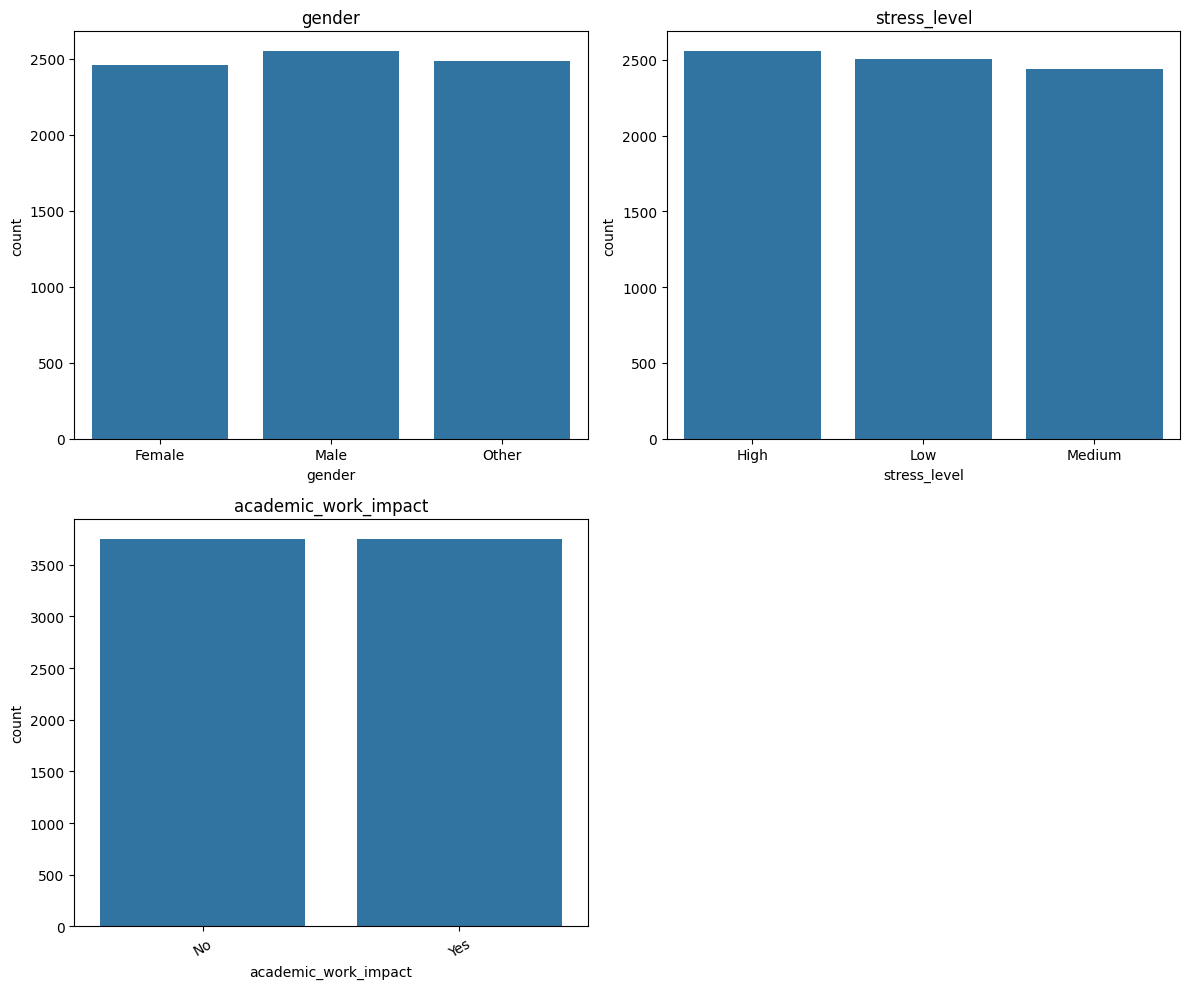

In [14]:
## understanding the interviewees population

import matplotlib.pyplot as plt
import seaborn as sns

cat_cols = ['gender', 'stress_level', 'academic_work_impact']

plt.figure(figsize=(12, 10))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 2, i)
    sns.countplot(data=df, x=col)
    plt.title(col)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [15]:
## making bins into age and seeing patterns

bins = np.arange(18,36,5)

labels = [f"{bins[i]}-{bins[i+1]-1}" for i in range(len(bins)-1)]

df['age_bin'] = pd.cut(df['age'], bins=bins, labels=labels, include_lowest=True)


In [16]:

activity_cols = [
    'daily_screen_time_hours',
    'social_media_hours',
    'gaming_hours',
    'work_study_hours',
    'sleep_hours',
    'notifications_per_day',
    'app_opens_per_day',
    'weekend_screen_time'
]


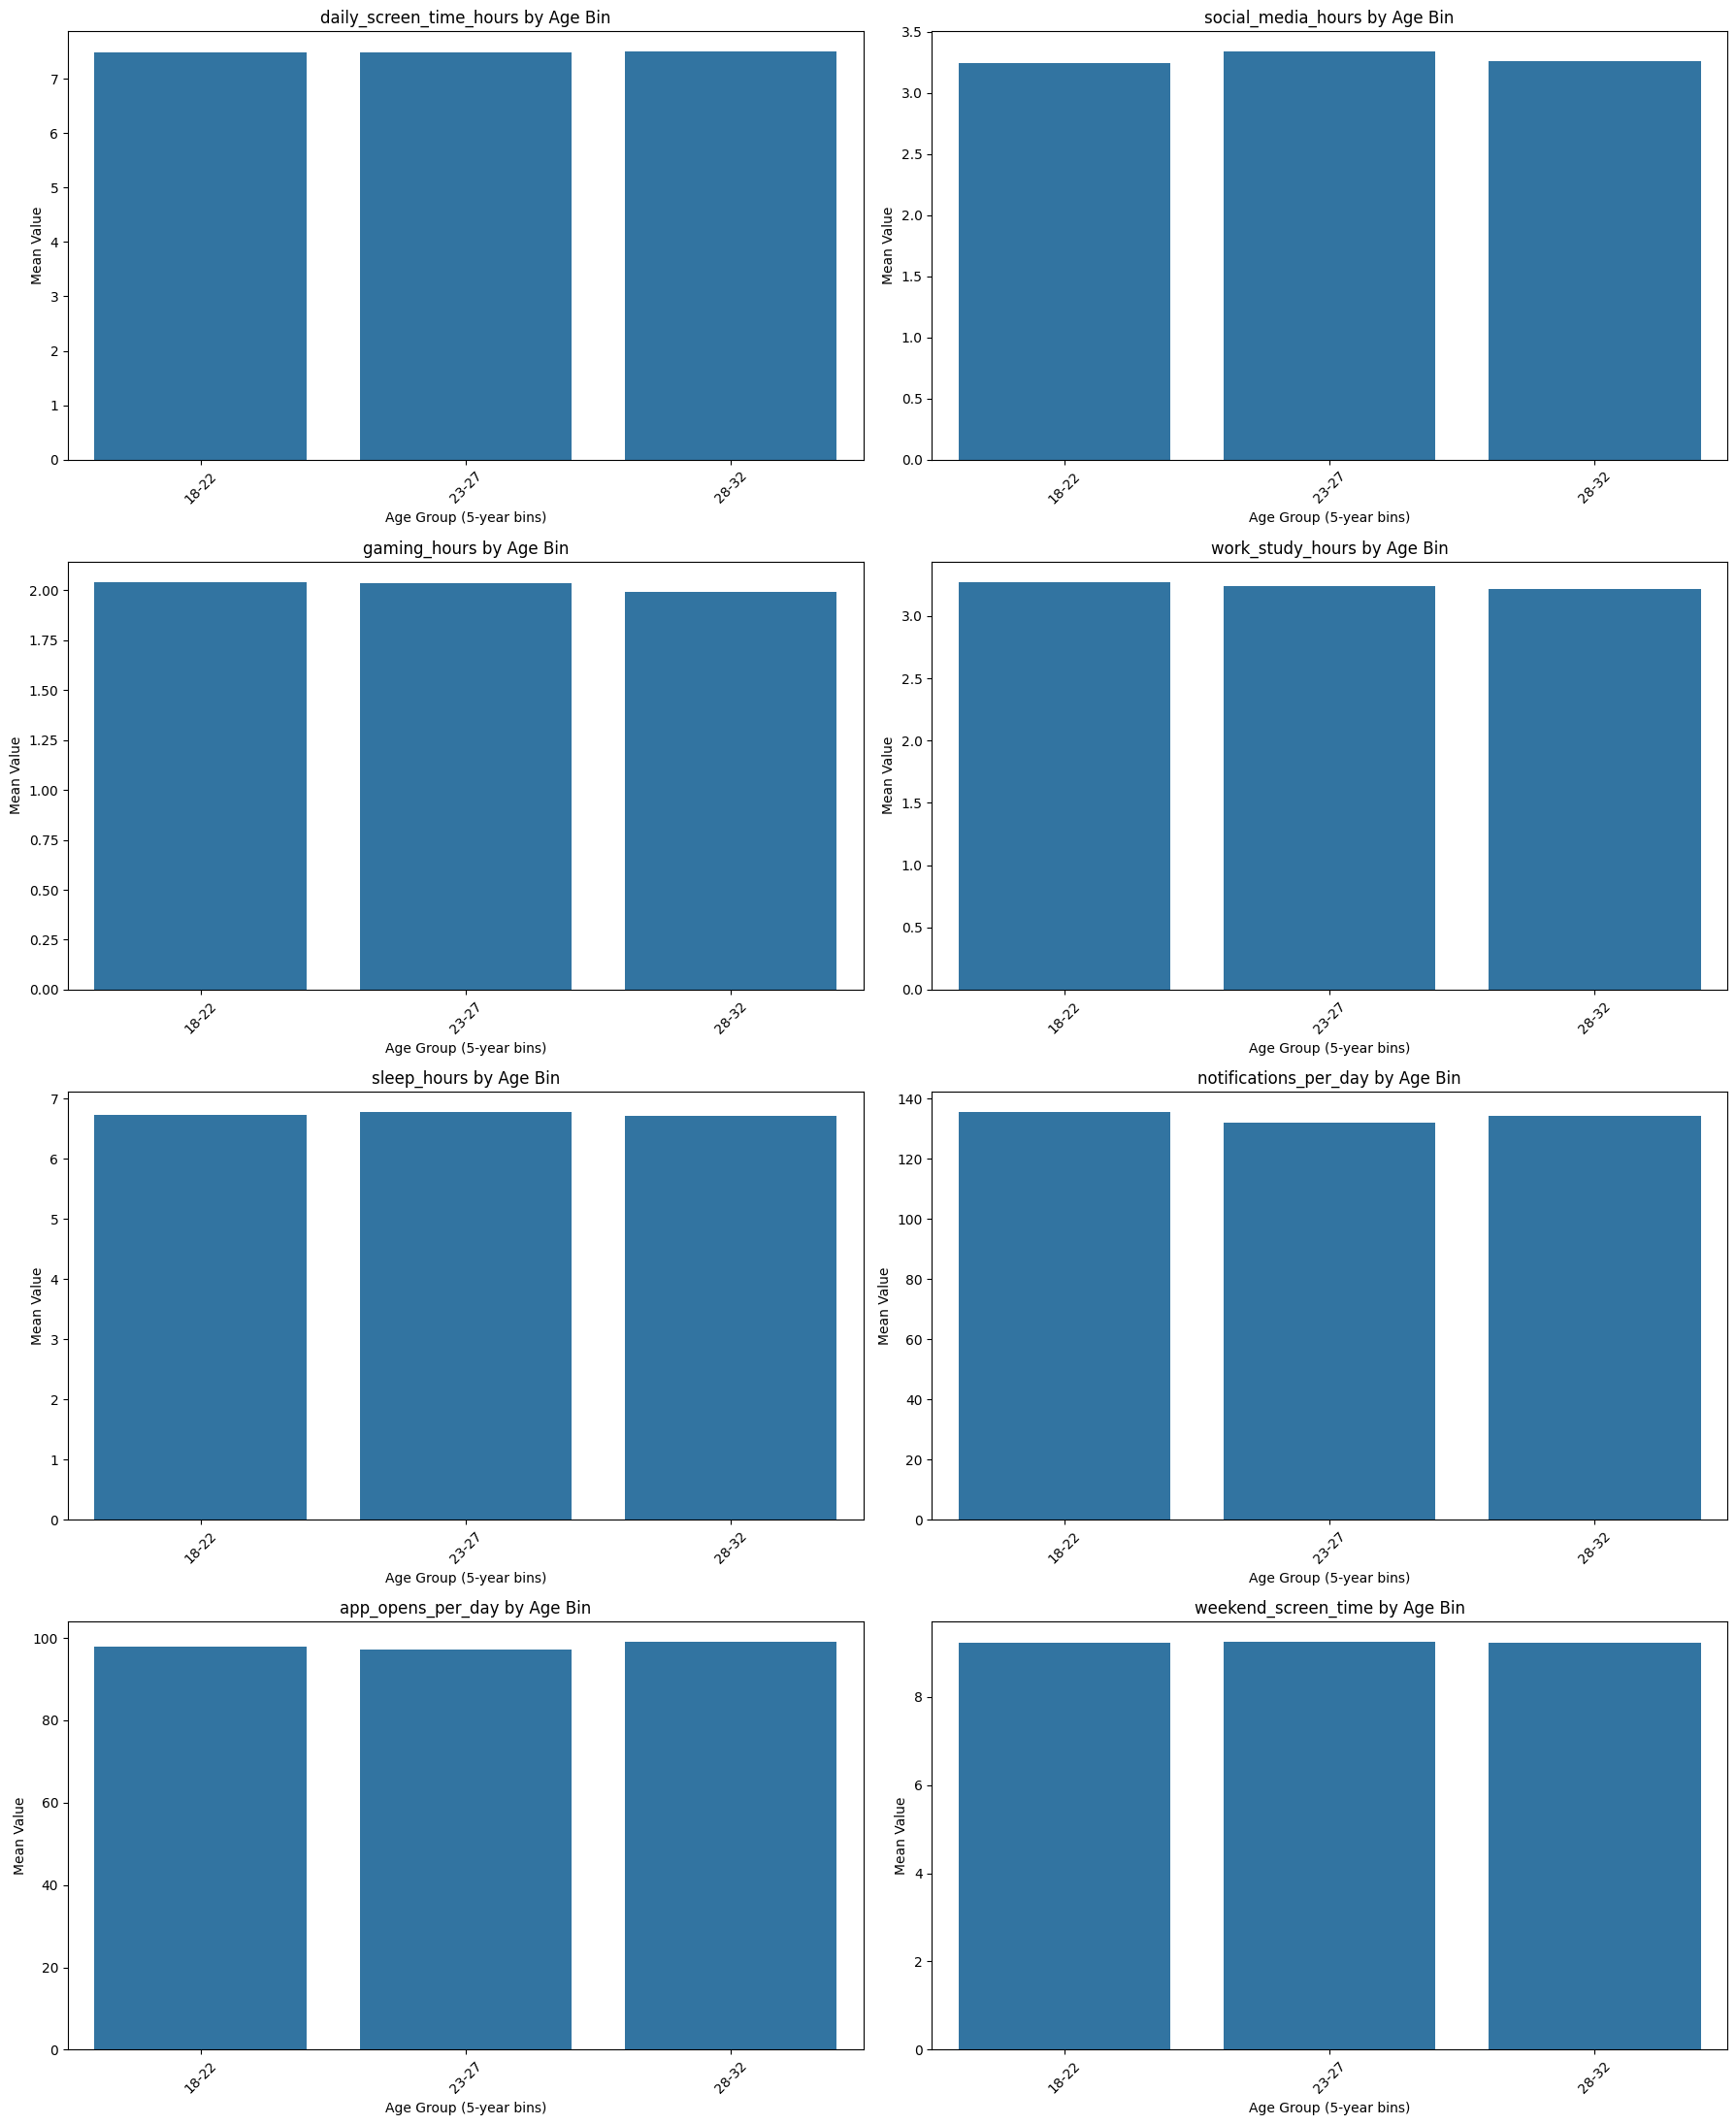

In [17]:


plt.figure(figsize=(18, 22))

for i, col in enumerate(activity_cols, 1):
    plt.subplot(4, 2, i)
    sns.barplot(data=df, x='age_bin', y=col, errorbar=None)
    plt.xticks(rotation=45)
    plt.title(f'{col} by Age Bin')
    plt.xlabel('Age Group (5-year bins)')
    plt.ylabel('Mean Value')

plt.tight_layout()
plt.show()

no much difference

/tmp/ipykernel_17/2544144304.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  activity_by_gender = df.groupby('gender')[activity_cols].mean().round(2)


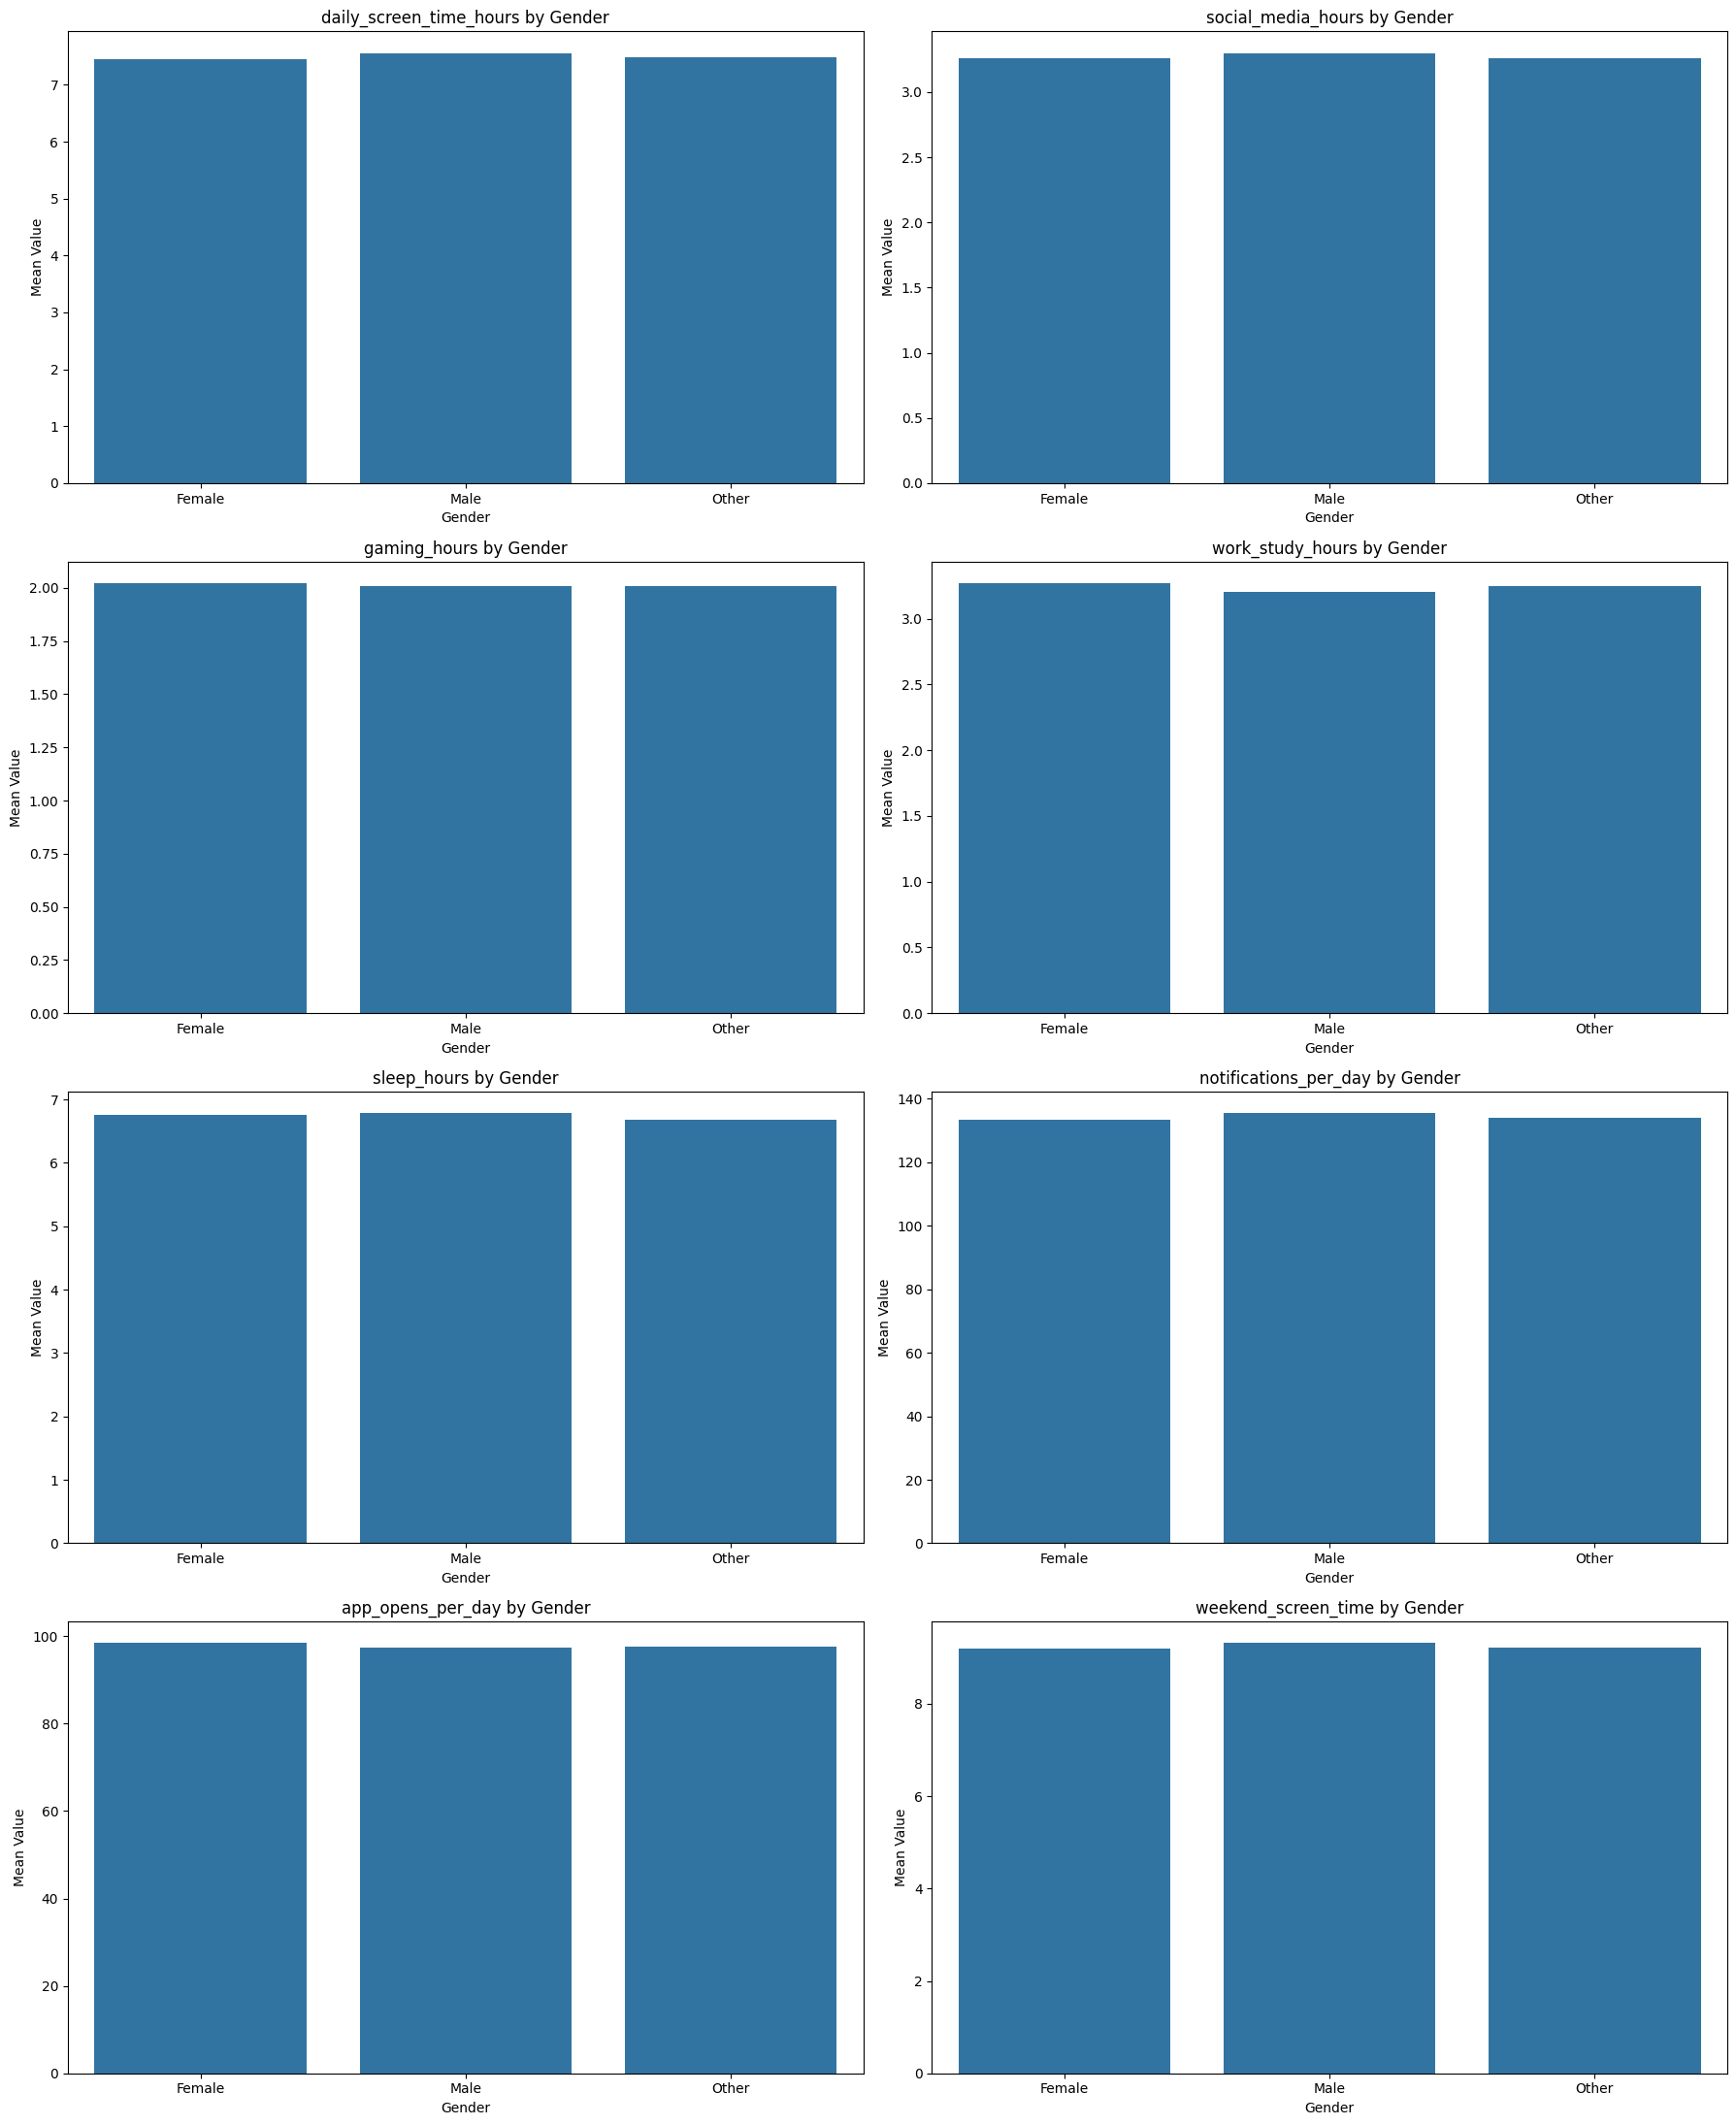

In [18]:
## seeing gender pattern
activity_by_gender = df.groupby('gender')[activity_cols].mean().round(2)
activity_by_gender

plt.figure(figsize=(18, 22))

for i, col in enumerate(activity_cols, 1):
    plt.subplot(4, 2, i)
    sns.barplot(data=df, x='gender', y=col, errorbar=None)
    plt.title(f'{col} by Gender')
    plt.xlabel('Gender')
    plt.ylabel('Mean Value')

plt.tight_layout()
plt.show()

also difference is not visible

These EDA visualizations are indicating there is no significant difference between age and gender on the activity level.I was thinking about the 'Other' in Gender, but it seems okay to include it for the later analysis

* ## 3. ML ##

we are predicting addiction_level_encoded

In [19]:
X = df.drop(columns=['addiction_level_encoded','transaction_id','user_id'])
y = df['addiction_level_encoded']

In [20]:
X = pd.get_dummies(X, drop_first=True)

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [22]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

In [23]:
y_pred = model.predict(X_test)

In [24]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          -1       0.56      0.41      0.48       164
           0       0.70      0.80      0.75       274
           1       0.57      0.60      0.59       575
           2       0.50      0.46      0.48       487

    accuracy                           0.57      1500
   macro avg       0.58      0.57      0.57      1500
weighted avg       0.57      0.57      0.57      1500



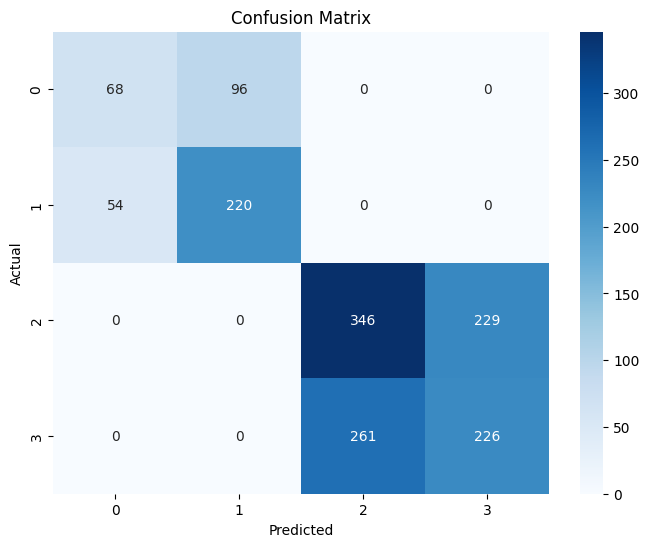

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [26]:

importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

for idx in indices[:15]:   # top 15 predictors
    print(f"{X.columns[idx]}: {importances[idx]:.4f}")


addicted_label: 0.2067
daily_screen_time_hours: 0.1653
weekend_screen_time: 0.1203
social_media_hours: 0.1160
gaming_hours: 0.0604
work_study_hours: 0.0602
sleep_hours: 0.0601
notifications_per_day: 0.0590
app_opens_per_day: 0.0588
age: 0.0398
academic_work_impact_Yes: 0.0091
gender_Other: 0.0084
gender_Male: 0.0079
stress_level_Low: 0.0079
stress_level_Medium: 0.0075


Interesting results here

do some linear regression as well

In [27]:
X = df.drop(columns=['addiction_level_encoded','transaction_id','user_id'])
y = df['addiction_level_encoded']
X = pd.get_dummies(X, drop_first=True)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [28]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [29]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000
)

log_reg.fit(X_train_scaled, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial')

In [30]:
y_pred = log_reg.predict(X_test_scaled)


In [31]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          -1       0.49      0.40      0.44       164
           0       0.68      0.74      0.71       274
           1       0.56      0.76      0.65       575
           2       0.52      0.31      0.39       487

    accuracy                           0.57      1500
   macro avg       0.56      0.55      0.55      1500
weighted avg       0.56      0.57      0.55      1500



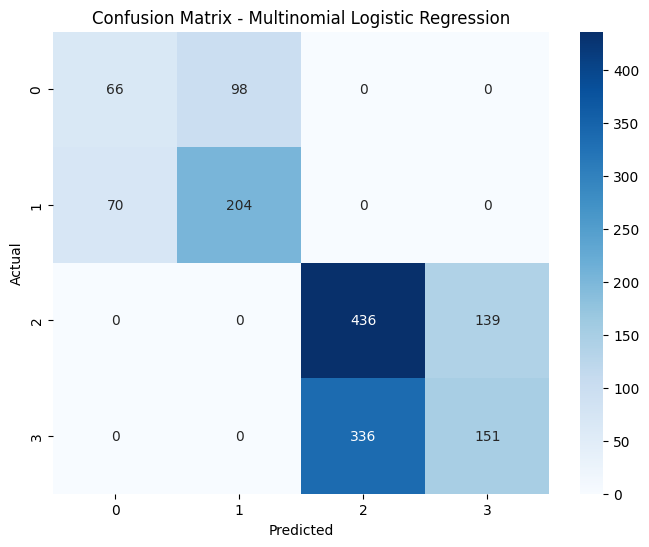

In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Multinomial Logistic Regression")
plt.show()

Only Moderate Result

Thanks for coming